# Advanced Process Mining Project – Group 1

## Setup

In [54]:
# Import necessary libraries
import numpy as np
import pandas as pd
import pm4py
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from datetime import datetime, timedelta, time

# Supress warnings
import warnings
warnings.filterwarnings('ignore') 

In [55]:
# Load the event logs
all_log = pm4py.read_xes('Event Logs/all.xes')
accepted_loans = pm4py.read_xes('Event Logs/accepted-loans.xes')
rejected_loans = pm4py.read_xes('Event Logs/rejected-loans.xes')
lcs_rejected_customers = pm4py.read_xes('Event Logs/lcs-rejected-customers.xes')
mid_rejected_customers = pm4py.read_xes('Event Logs/mid-rejected-customers.xes')
mla_rejected_customers = pm4py.read_xes('Event Logs/mla-rejected-customers.xes')

parsing log, completed traces :: 100%|██████████| 392/392 [00:00<00:00, 3113.25it/s]


## <b>Question 1</b>: Initial Overview

In [ ]:
print(f'Shape: {all_log.shape}')
all_log.head(3)

Shape: (47553, 27)


,concept:name,time:timestamp,org:resource,lifecycle:transition,case:concept:name,case:customer_id,case:customer_name,case:customer_ssid,case:loan_amount,case:case_creation_no,...,loan_decision,loan_decision_extra,interest,loan_term_years,recipient,transfer_amount,repayments,installment_target,repaid_amount,cumulatively_repaid
0,Application Registered,2021-01-03 09:04:01+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Retrieve Identity Document,2021-01-03 09:04:02+00:00,System Resource,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Retrieve Internal Log Data,2021-01-03 10:12:01+00:00,Risk Assessment System,complete,470-16,470,Customer 470,6c710e01-8262-41dd-8476-688b1513d23c,500.0,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### <b>1a.</b> How many cases, events, and unique activities does the event log contain?

Additionally, what is the timeframe covered by the log (i.e., the duration between the
earliest and latest recorded event)?

In [57]:
# Counts
num_cases = all_log['case:concept:name'].nunique()
num_events = len(all_log)
num_activities = all_log['concept:name'].nunique()

# Timeframe 
timestamps = pd.to_datetime(all_log['time:timestamp'], utc=True)    # Convert everythingto UTC to avoid timezone issues
earliest = timestamps.min()
latest = timestamps.max()
timeframe = latest - earliest          

# Print results
print('=' * 55)
print('  EVENT LOG – BASIC STATISTICS')
print('=' * 55)
print(f'  Number of cases             : {num_cases}')
print(f'  Number of events            : {num_events}')
print(f'  Number of unique activities : {num_activities}')
print(f'  Earliest event              : {earliest}')
print(f'  Latest event                : {latest}')
print(f'  Log timeframe               : {timeframe}')
print('=' * 55)

  EVENT LOG – BASIC STATISTICS
  Number of cases             : 1820
  Number of events            : 47553
  Number of unique activities : 26
  Earliest event              : 2021-01-01 00:00:01+00:00
  Latest event                : 2023-09-13 09:00:03+00:00
  Log timeframe               : 985 days 09:00:02


In [66]:
print('Unique activities:')
for i, act in enumerate(sorted(all_log['concept:name'].unique()), 1):
    print(f'  {i}. {act}')

Unique activities:
  1. Accelerate Loan (Force Default)
  2. Accept Terms
  3. Application Registered
  4. Confirmed Identity
  5. Create Assessment Report
  6. Decide Loan Application
  7. Formally Initiate Debt Recovery
  8. Installment Received
  9. Loan Default Notice Received
  10. Query Central Bank System
  11. Query Credit Bureau
  12. Received Terms Acceptance
  13. Reject Application
  14. Repayment Completed
  15. Request to Defer Payment Received
  16. Retrieve Customer Global Risk Score
  17. Retrieve Financial Status
  18. Retrieve Identity Document
  19. Retrieve Internal Log Data
  20. Send Acceptance Confirmation
  21. Send Rejection Notification
  22. Send to Collections
  23. Start Repayments
  24. Transfer Funds
  25. Verify ID Automatically
  26. Verify ID Manually


### <b>1b.</b> How many variants are present in the log? What is the average number of events per case?

In [68]:
# Variants
variants_dict = pm4py.get_variants(all_log)
num_variants = len(variants_dict)

# Average events per case
events_per_case = all_log.groupby('case:concept:name').size()

# Print results
print('=' * 40)
print('  VARIANTS & TRACE LENGTH')
print('=' * 40)
print(f'  Number of variants      : {num_variants}')
print(f'  Average events per case : {events_per_case.mean():0.2f}')
print(f'  Min events in a case    : {events_per_case.min()}')
print(f'  Max events in a case    : {events_per_case.max()}')
print('=' * 40)

  VARIANTS & TRACE LENGTH
  Number of variants      : 678
  Average events per case : 26.13
  Min events in a case    : 11
  Max events in a case    : 44


### <b>1c.</b> Which event attributes and case attributes are included in the log? 

Relate each event attribute to the corresponding activity or activities.

In [ ]:
# Separate case columns
all_cols = all_log.columns.tolist()
case_cols = [c for c in all_cols if c.startswith('case:')]

print('CASE ATTRIBUTES')
print('-' * 65)
for col in case_cols:
    n_unique = all_log[col].nunique()
    sample = all_log[col].dropna().iloc[0] if all_log[col].notna().any() else 'N/A'
    print(f'  {col:<25}  unique: {n_unique:<6}  sample: {sample}')

CASE ATTRIBUTES
-----------------------------------------------------------------
  case:concept:name          unique: 1820    sample: 470-16
  case:customer_id           unique: 877     sample: 470
  case:customer_name         unique: 877     sample: Customer 470
  case:customer_ssid         unique: 877     sample: 6c710e01-8262-41dd-8476-688b1513d23c
  case:loan_amount           unique: 5       sample: 500.0
  case:case_creation_no      unique: 1820    sample: 16


In [72]:
# Separate event columns
std_cols = {'case:concept:name', 'concept:name', 'time:timestamp',
              '@@index', '@@case_index'}
event_cols = [c for c in all_cols
              if not c.startswith('case:') and c not in std_cols]

print('EVENT ATTRIBUTES')
print('-' * 75)
for col in event_cols:
    n_nn   = all_log[col].notna().sum()
    sample = all_log[col].dropna().iloc[0] if n_nn > 0 else 'N/A'
    print(f'  {col:<32}  non-null: {n_nn:<8}  sample: {sample}')

EVENT ATTRIBUTES
---------------------------------------------------------------------------
  org:resource                      non-null: 47553     sample: System Resource
  lifecycle:transition              non-null: 47553     sample: complete
  prior_defaults                    non-null: 3559      sample: []
  prior_applications                non-null: 3559      sample: []
  auto_id_verification_outcome      non-null: 1820      sample: valid
  risk_score                        non-null: 3559      sample: 0.56
  credit_score                      non-null: 3559      sample: 439.93
  code                              non-null: 323       sample: LCS
  manual_id_verification_outcome    non-null: 350       sample: invalid
  loan_decision                     non-null: 1732      sample: reject
  loan_decision_extra               non-null: 1732      sample: {'msg': 'loan applications are too close', 'code': 'MLA'}
  interest                          non-null: 1499      sample: 0.05
  loan_t

In [62]:
# Relate each event attribute to the activities where it appears

print('EVENT ATTRIBUTE  ->  ACTIVITY MAPPING')
print('=' * 70)
for col in event_cols:
    subset = all_log[all_log[col].notna()]
    if subset.empty:
        print(f'  Attribute : "{col}" - always null')
        continue
    activities = sorted(subset['concept:name'].unique())
    print(f'  Attribute : "{col}"')
    print(f'  Appears in: {activities}')
    print()

EVENT ATTRIBUTE  ->  ACTIVITY MAPPING
  Attribute : "org:resource"
  Appears in: ['Accelerate Loan (Force Default)', 'Accept Terms', 'Application Registered', 'Confirmed Identity', 'Create Assessment Report', 'Decide Loan Application', 'Formally Initiate Debt Recovery', 'Installment Received', 'Loan Default Notice Received', 'Query Central Bank System', 'Query Credit Bureau', 'Received Terms Acceptance', 'Reject Application', 'Repayment Completed', 'Request to Defer Payment Received', 'Retrieve Customer Global Risk Score', 'Retrieve Financial Status', 'Retrieve Identity Document', 'Retrieve Internal Log Data', 'Send Acceptance Confirmation', 'Send Rejection Notification', 'Send to Collections', 'Start Repayments', 'Transfer Funds', 'Verify ID Automatically', 'Verify ID Manually']

  Attribute : "lifecycle:transition"
  Appears in: ['Accelerate Loan (Force Default)', 'Accept Terms', 'Application Registered', 'Confirmed Identity', 'Create Assessment Report', 'Decide Loan Application', 'F

### <b>1d.</b> Analyze the frequency distribution of variants.

Create a plot with variant frequency on
the y-axis and variants on the x-axis, sorted in descending order of frequency. What insights can you derive about
the process?

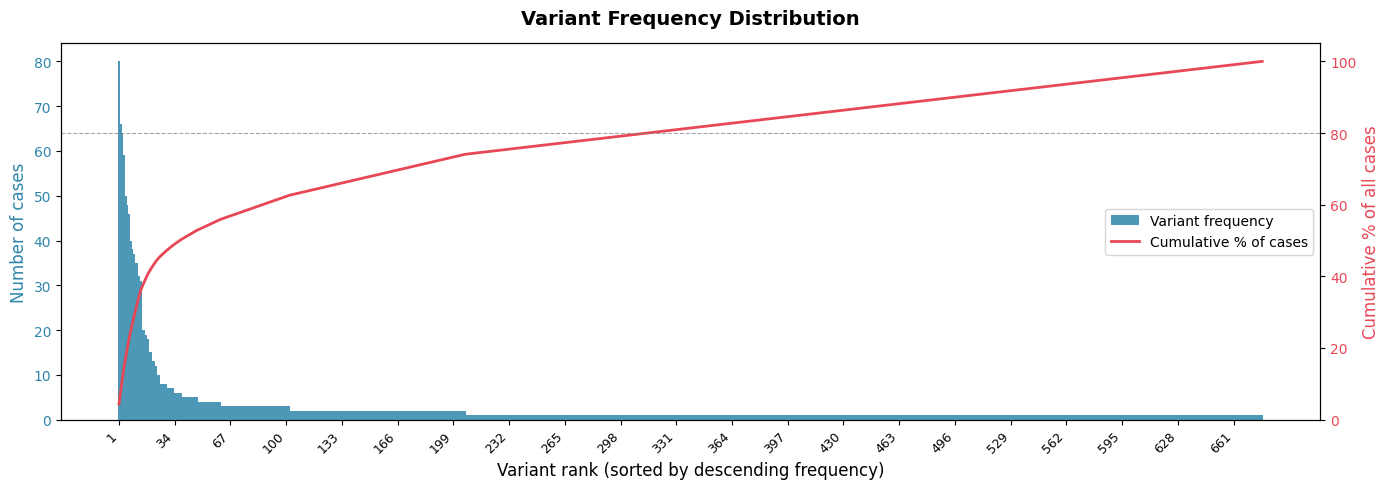

Top-1  variant covers : 4.4% of all cases
Top-5  variants cover : 17.5% of all cases
Top-10 variants cover : 29.0% of all cases
80% of cases covered by top-314 variant(s)
Remaining 364 variants cover the last 20% of cases


In [ ]:
# Build sorted frequency series
variant_freq = pd.Series(
    {v: len(cases) if not isinstance(cases, int) else cases
     for v, cases in variants_dict.items()},
    name='frequency'
).sort_values(ascending=False)

ranks = list(range(1, len(variant_freq) + 1))
freqs = variant_freq.values
cum_pct = np.cumsum(freqs) / freqs.sum() * 100   # cumulative percentage

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart of frequencies
ax1.bar(ranks, freqs, color='#2E86AB', alpha=0.85, width=1.0, label='Variant frequency')
ax1.set_xlabel('Variant rank (sorted by descending frequency)', fontsize=12)
ax1.set_ylabel('Number of cases', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Show x-ticks sparsely so labels do not overlap
tick_step = max(1, len(ranks) // 20)
ax1.set_xticks(ranks[::tick_step])
ax1.set_xticklabels(ranks[::tick_step], rotation=45, ha='right', fontsize=9)

# Cumulative line on secondary axis
ax2 = ax1.twinx()
ax2.plot(ranks, cum_pct, color='#E84855', linewidth=2, label='Cumulative % of cases')
ax2.axhline(80, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_ylabel('Cumulative % of all cases', fontsize=12, color='#E84855')
ax2.tick_params(axis='y', labelcolor='#E84855')
ax2.set_ylim(0, 105)

plt.title('Variant Frequency Distribution', fontsize=14, fontweight='bold', pad=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)
plt.tight_layout()
plt.savefig('variant_frequency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Supporting numbers
top1 = freqs[0] / freqs.sum() * 100
top5 = freqs[:5].sum() / freqs.sum() * 100
top10 = freqs[:10].sum() / freqs.sum() * 100
idx80 = int(np.searchsorted(cum_pct, 80))

print(f'Top-1  variant covers : {top1:.1f}% of all cases')
print(f'Top-5  variants cover : {top5:.1f}% of all cases')
print(f'Top-10 variants cover : {top10:.1f}% of all cases')
print(f'80% of cases covered by top-{idx80+1} variant(s)')
print(f'Remaining {len(ranks)-(idx80+1)} variants cover the last 20% of cases')

The distribution is highly right-skewed: a small number of variants account for the majority of cases, while most variants appear only ones or twice. This indicates that the process has a few dominant paths, but also a long tail of exceptions caused by re-submissions, document corrections, or manual overrides. The fact that 80% of cases are covered only after hundreds of variants suggests process complexity and fragmentation from the main flows.

### <b>1e.</b> Examine the distribution of case durations. 

Report the minimum, maximum, mean, median, and standard deviation of case duration.
What insights can you derive about the process? (approx. 3–4 sentences)

In [64]:
# Compute case durations
duration_df = (
    all_log
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
    .rename(columns={'min': 'start', 'max': 'end'})
)
duration_df['start'] = pd.to_datetime(duration_df['start'], utc=True)
duration_df['end']   = pd.to_datetime(duration_df['end'],   utc=True)

# Transform the values into hours and days
duration_df['duration_hours'] = (
    (duration_df['end'] - duration_df['start']).dt.total_seconds() / 3600
)
duration_df['duration_days'] = duration_df['duration_hours'] / 24

dur_h = duration_df['duration_hours']
dur_d = duration_df['duration_days']

# Descriptive statistics
stats = {
    'Minimum'         : (dur_h.min(),         dur_d.min()),
    'Maximum'         : (dur_h.max(),         dur_d.max()),
    'Mean'            : (dur_h.mean(),        dur_d.mean()),
    'Median'          : (dur_h.median(),      dur_d.median()),
    'Std deviation'   : (dur_h.std(),         dur_d.std()),
    '25th percentile' : (dur_h.quantile(0.25), dur_d.quantile(0.25)),
    '75th percentile' : (dur_h.quantile(0.75), dur_d.quantile(0.75)),
}

print('=' * 55)
print('  CASE DURATION STATISTICS')
print('=' * 55)
print(f'  {"Metric":<22}  {"Hours":>10}  {"Days":>10}')
print('-' * 55)
for label, (h, d) in stats.items():
    print(f'  {label:<22}  {h:>10.2f}  {d:>10.2f}')
print('=' * 55)

  CASE DURATION STATISTICS
  Metric                       Hours        Days
-------------------------------------------------------
  Minimum                       6.10        0.25
  Maximum                   18202.47      758.44
  Mean                       7009.24      292.05
  Median                     5300.63      220.86
  Std deviation              5298.31      220.76
  25th percentile            4530.46      188.77
  75th percentile            9577.69      399.07


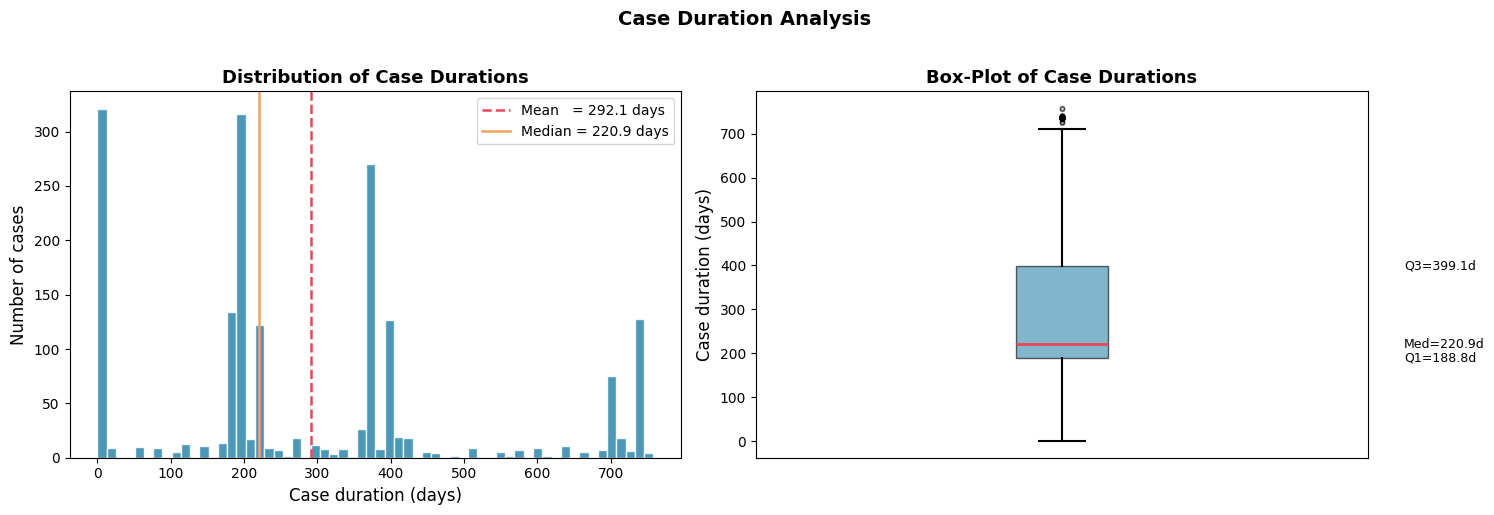

Cases with duration less than 1 day : 161
Cases longer than 30 days           : 1,490
Cases longer than 365 days          : 745
Mean/Median gap (days)              : 71.19


In [79]:
# Plot: Histogram + Box-plot 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram 
ax = axes[0]
ax.hist(dur_d, bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.axvline(dur_d.mean(),   color='#E84855', linestyle='--', linewidth=1.8,
           label=f'Mean   = {dur_d.mean():.1f} days')
ax.axvline(dur_d.median(), color='#F4A261', linestyle='-',  linewidth=1.8,
           label=f'Median = {dur_d.median():.1f} days')
ax.set_xlabel('Case duration (days)', fontsize=12)
ax.set_ylabel('Number of cases',      fontsize=12)
ax.set_title('Distribution of Case Durations', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Right: box-plot 
ax2 = axes[1]
ax2.boxplot(
    dur_d, vert=True, patch_artist=True,
    boxprops=dict(facecolor='#2E86AB', alpha=0.6),
    medianprops=dict(color='#E84855', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.3, color='grey')
)
ax2.set_ylabel('Case duration (days)', fontsize=12)
ax2.set_title('Box-Plot of Case Durations',
              fontsize=13, fontweight='bold')
ax2.set_xticks([])

# Annotate quartiles
q1, med, q3 = dur_d.quantile(0.25), dur_d.median(), dur_d.quantile(0.75)
for val, lbl in [(q1, f'Q1={q1:.1f}d'), (med, f'Med={med:.1f}d'), (q3, f'Q3={q3:.1f}d')]:
    ax2.annotate(lbl, xy=(1.06, val), xycoords=('axes fraction', 'data'),
                 fontsize=9, va='center')

plt.suptitle('Case Duration Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('case_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional detail
zero_dur = (dur_d <= 1).sum()
over30d  = (dur_d > 30).sum()
over365d  = (dur_d > 365).sum()
print(f'Cases with duration less than 1 day : {zero_dur:,}')
print(f'Cases longer than 30 days           : {over30d:,}')
print(f'Cases longer than 365 days          : {over365d:,}')
print(f'Mean/Median gap (days)              : {dur_d.mean() - dur_d.median():.2f}')

The distribution is strongly right-skewed, with the mean much higher than the median, indicating the presence of very long cases pulling the average upward. Cases with duration near zero suggest automated fast-track rejections. While most cases take around ~180–230 days, a significant number extend far beyond that number, probably pointing to exceptional cases. 
<br> Overall, the wide range and large standard deviation suggest high variability and inconsistent processing times. 

## <b>Question 2</b>: General Visual Analytics & Exploration

## <b>Question 3</b>: Use Case-Specific Visual Analytics & Exploration

## <b>Question 4</b>: Process Discovery

## <b>Question 5</b>: Conformance Checking